In [105]:
import numpy as np
import pandas as pd

import json as json
import matplotlib.pyplot as plt
import seaborn as sns

In [106]:
plt.style.use('thesis_b5')
full_width, full_height = plt.rcParams['figure.figsize']

plt.rcParams['xtick.major.pad'] = 1
plt.rcParams['ytick.major.pad'] = 1

%config InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0}

In [107]:
df = pd.read_csv("results_data/rewiring_edges_pairwise_method_agreement_long.csv")

## Taking Mean over results

In [39]:
all_counts_dataframe.applymap(lambda x: np.mean(x))

,Texas,Cornell
0,74.259259,66.666667
1,60.185185,66.666667
2,67.222222,66.666667
3,34.074074,66.666667
4,3.333333,66.666667


## Taking Std over results

In [41]:
all_counts_dataframe.applymap(lambda x: np.std(x))

,Texas,Cornell
0,3.218175,23.570226
1,10.718368,23.570226
2,6.136312,23.570226
3,11.700421,23.570226
4,4.714045,23.570226


## Pairwise agreement heatmaps per dataset

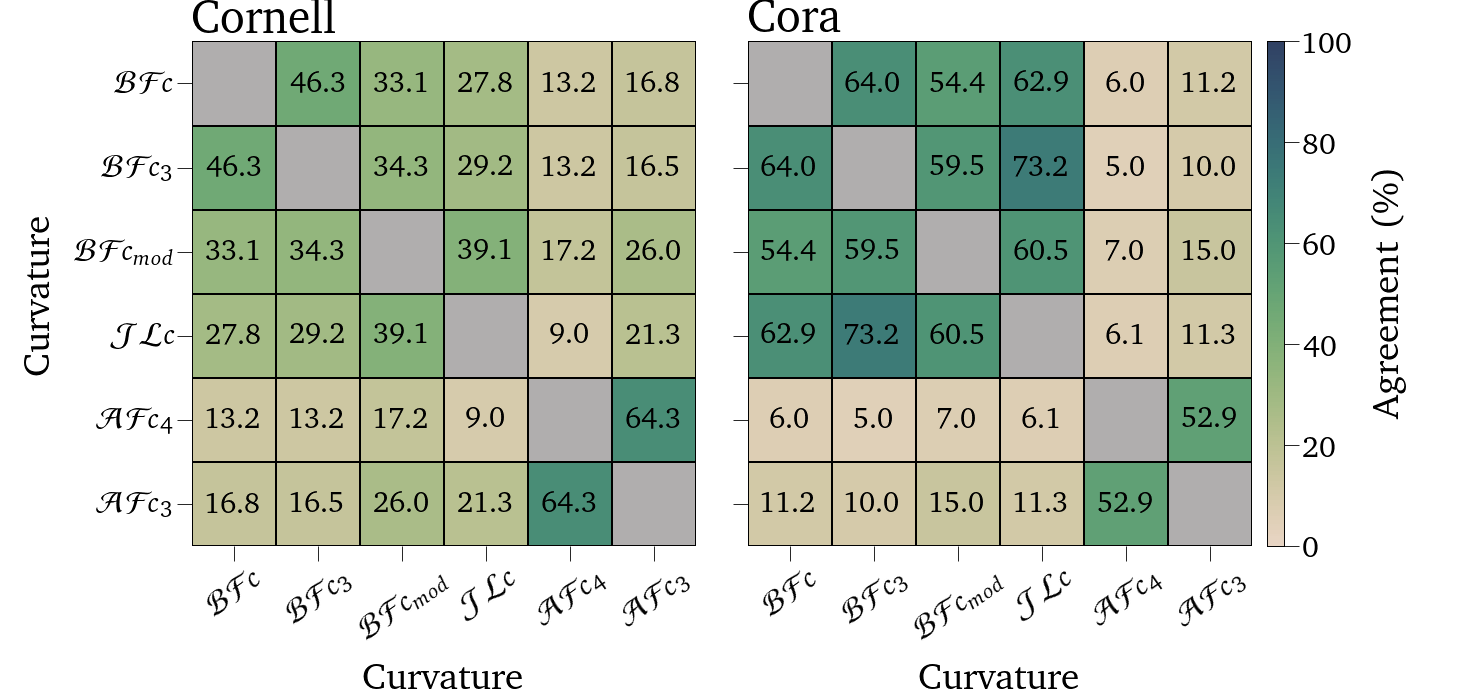

In [122]:

desired_order = ["BFc_w4cycle", "BFc_no4cycle", "BFc_mod", "JLc", "AFc_4", "AFc_3"]
label_map = {
    "BFc_w4cycle": r"$\mathcal{BF}c$",
    "BFc_no4cycle": r"$\mathcal{BF}c_3$",
    "BFc_mod": r"$\mathcal{BF}c_{mod}$",
    "JLc": r"$\mathcal{JL}c$",
    "AFc_4": r"$\mathcal{AF}c_4$",
    "AFc_3": r"$\mathcal{AF}c_3$",
}

heatmap_cmap = sns.cubehelix_palette(start=.5, dark=0.25, rot=-0.9, as_cmap=True)

pairwise_mean = (
    df.groupby(["dataset", "method_a", "method_b"], as_index=False)["agreement_pct"]
    .mean()
)

# Create figure with equal-size heatmap axes and a dedicated colorbar axis
fig = plt.figure(figsize=(full_width, full_height / 3), dpi=300)
fig.subplots_adjust(left=0.13, right=0.90, bottom=0.18, top=0.98)
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.15)
axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
cbar_ax = fig.add_subplot(gs[0, 2])

datasets = ["Cornell", "Cora"]

for idx, dataset_name in enumerate(datasets):
    subset = pairwise_mean[pairwise_mean["dataset"] == dataset_name]

    methods = sorted(set(subset["method_a"]).union(set(subset["method_b"])))
    matrix = pd.DataFrame(index=methods, columns=methods, dtype=float)

    for _, row in subset.iterrows():
        method_a = row["method_a"]
        method_b = row["method_b"]
        value = row["agreement_pct"]
        matrix.loc[method_a, method_b] = value
        matrix.loc[method_b, method_a] = value

    ordered_methods = [method for method in desired_order if method in matrix.index]
    matrix = matrix.reindex(index=ordered_methods, columns=ordered_methods)

    display_labels = [label_map[method] for method in ordered_methods]
    diag_mask = np.eye(len(matrix), dtype=bool)

    axes[idx].set_facecolor("#B0AEAE")
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".1f",
        cmap=heatmap_cmap,
        vmin=0,
        vmax=100,
        linewidths=0.01,
        linecolor='black',
        square=True,
        mask=diag_mask,
        cbar=(idx == 1),
        cbar_ax=cbar_ax if idx == 1 else None,
        cbar_kws={"label": r"Agreement ($\%$)"} if idx == 1 else None,
        ax=axes[idx],
        annot_kws={"fontsize": 7,'color':'black'}
    )

    axes[idx].set_xticklabels(display_labels, rotation=35)
    axes[idx].text(0.0, 1.00, dataset_name, ha='left', va='bottom', transform=axes[idx].transAxes, fontsize=11)
    axes[idx].set_xlabel("Curvature")

    if idx == 0:
        axes[idx].set_ylabel("Curvature")
        axes[idx].set_yticklabels(display_labels, rotation=0)
    else:
        axes[idx].set_ylabel("")
        axes[idx].set_yticklabels([])

# Match colorbar height exactly to the right heatmap axis
right_pos = axes[1].get_position()
cbar_ax.set_position([right_pos.x1 + 0.01, right_pos.y0, 0.012, right_pos.height])
for spine in cbar_ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("black")
    spine.set_linewidth(0.2)

plt.savefig("results_figures/rewiring_edges_pairwise_method_agreement_heatmaps.pdf")
